# eval_01 — degrade → reconstruct (v0 harness)

Ground truth = one hand-digitized Bregel polygon. We simulate a *rough human trace*
(fewer vertices + positional error), run a (trivial, for now) reconstruction, and
score recovery with **area IoU** and **Hausdorff distance**, computed in a projected
(metric) CRS.

Framing: `docs/GPT_20260828.txt` §§257–271 — the point is an objective recovery
metric, not "did the machine digitize the map?". v0 establishes the measurement
frame; real extraction methods slot into `reconstruct()` later.

In [ ]:
import json
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from shapely.geometry import shape, Polygon
from shapely.ops import transform as shp_transform
from pyproj import CRS, Transformer

# Ignore the user's global ~/.matplotlib/matplotlibrc (dark theme + a malformed
# line) so figures are reproducible and legible regardless of local config.
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

DATA = Path("data")

## 1. Load ground truth

In [ ]:
def load_features(path, geom_type=None):
    fc = json.loads(Path(path).read_text())
    feats = fc["features"]
    if geom_type:
        feats = [f for f in feats if f["geometry"]["type"] == geom_type]
    return feats

polys = load_features(DATA / "bregel_37.geojson", "Polygon")
lines = load_features(DATA / "bregel_39.geojson", "LineString")
print(len(polys), "polygons,", len(lines), "linestrings")

# work with one non-trivial polygon (most exterior vertices)
gt_feat = max(polys, key=lambda f: len(f["geometry"]["coordinates"][0]))
gt = shape(gt_feat["geometry"])
name = (gt_feat.get("properties", {}).get("names") or [{}])[0].get("toponym") or gt_feat.get("title")
print(f"chosen: {name!r} | exterior vertices: {len(gt.exterior.coords)} | valid: {gt.is_valid}")

## 2. Project to a metric CRS

Distances/areas need meters, not degrees. Pick the UTM zone under the polygon centroid.

In [ ]:
def utm_epsg_for(geom_ll):
    c = geom_ll.centroid
    zone = int((c.x + 180) // 6) + 1
    return 32600 + zone + (0 if c.y >= 0 else 100)

PROJ = CRS.from_epsg(utm_epsg_for(gt))
fwd = Transformer.from_crs(4326, PROJ, always_xy=True).transform
inv = Transformer.from_crs(PROJ, 4326, always_xy=True).transform
to_m  = lambda g: shp_transform(fwd, g)
to_ll = lambda g: shp_transform(inv, g)

gt_m = to_m(gt)
print(f"{PROJ.to_epsg()} {PROJ.name}")
print(f"area {gt_m.area/1e6:,.1f} km^2   perimeter {gt_m.length/1e3:,.1f} km")

## 3. Degradation model

Stand-in for a human's rough trace: even arc-length resample to `n_points`
vertices, then add Gaussian positional error of `jitter_m` meters.

In [ ]:
rng = np.random.default_rng(42)

def degrade(poly_m, n_points, jitter_m):
    ring = np.array(poly_m.exterior.coords)[:-1]                 # drop closing dup
    seglen = np.hypot(*np.diff(ring, axis=0, append=ring[:1]).T)
    d = np.r_[0.0, np.cumsum(seglen)][:-1]
    s = np.linspace(0, d[-1], n_points, endpoint=False)
    xy = np.c_[np.interp(s, d, ring[:, 0]), np.interp(s, d, ring[:, 1])]
    xy = xy + rng.normal(0, jitter_m, xy.shape)
    return Polygon(xy)

rough = degrade(gt_m, n_points=12, jitter_m=25)

## 4. Reconstruction

v0 is deliberately trivial — identity with a validity fix. Real methods replace the body of `reconstruct()`.

In [ ]:
def reconstruct(rough_poly):
    g = rough_poly.buffer(0)
    if g.is_empty:
        return Polygon()
    if g.geom_type == "MultiPolygon":
        return max(g.geoms, key=lambda p: p.area)
    return g if g.geom_type == "Polygon" else Polygon()

recon = reconstruct(rough)

## 5. Metrics

In [ ]:
def iou(a, b):
    a, b = a.buffer(0), b.buffer(0)
    if a.is_empty and b.is_empty:
        return 1.0
    inter = a.intersection(b).area
    union = a.area + b.area - inter
    return inter / union if union else 0.0

def hausdorff(a, b):
    if a.is_empty or b.is_empty:
        return float("nan")
    return a.hausdorff_distance(b)

print(f"IoU        {iou(gt_m, recon):.3f}")
print(f"Hausdorff  {hausdorff(gt_m, recon):,.0f} m")

## 6. Look at one case

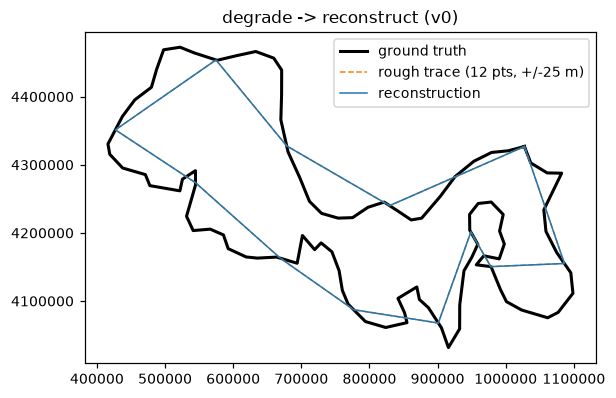

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
for g, kw in [
    (gt_m,  dict(color="black",      lw=2,           label="ground truth")),
    (rough, dict(color="tab:orange", lw=1, ls="--",  label="rough trace (12 pts, +/-25 m)")),
    (recon, dict(color="tab:blue",   lw=1,           label="reconstruction")),
]:
    if not g.is_empty:
        x, y = g.exterior.xy
        ax.plot(x, y, **kw)
ax.set_aspect("equal")
ax.ticklabel_format(style="plain")
ax.legend(labelcolor="black")
ax.set_title("degrade -> reconstruct (v0)")
plt.show()

## 7. Sweep: N points x positional error

Averaged over a few random degradations per cell.

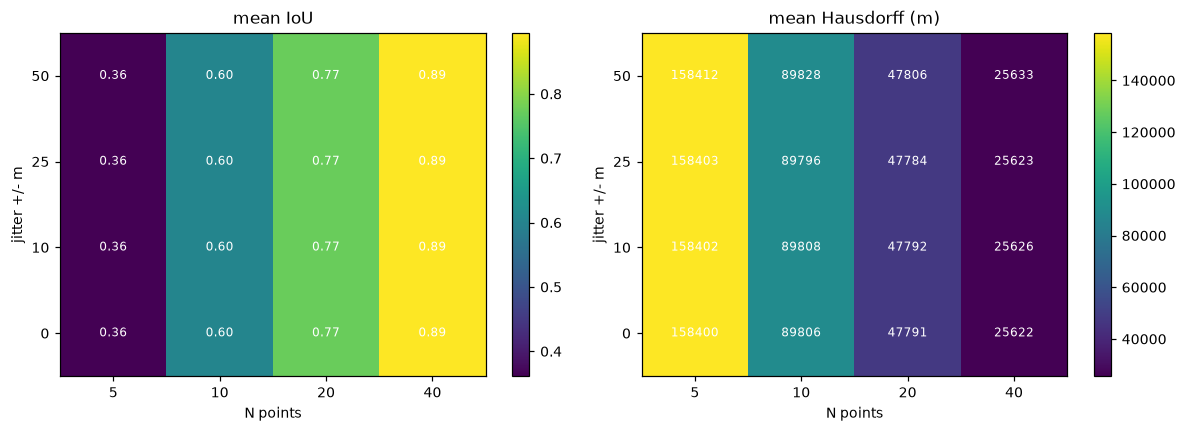

In [8]:
Ns = [5, 10, 20, 40]
Ms = [0, 10, 25, 50]
reps = 5

iou_grid  = np.zeros((len(Ms), len(Ns)))
haus_grid = np.zeros((len(Ms), len(Ns)))
for i, m in enumerate(Ms):
    for j, n in enumerate(Ns):
        vals = [(lambda r: (iou(gt_m, r), hausdorff(gt_m, r)))(reconstruct(degrade(gt_m, n, m)))
                for _ in range(reps)]
        iou_grid[i, j]  = np.nanmean([v[0] for v in vals])
        haus_grid[i, j] = np.nanmean([v[1] for v in vals])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, grid, title, fmt in [
    (axes[0], iou_grid,  "mean IoU",            "{:.2f}"),
    (axes[1], haus_grid, "mean Hausdorff (m)",  "{:.0f}"),
]:
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(Ns)), Ns)
    ax.set_yticks(range(len(Ms)), Ms)
    ax.set_xlabel("N points")
    ax.set_ylabel("jitter +/- m")
    ax.set_title(title)
    for i in range(len(Ms)):
        for j in range(len(Ns)):
            ax.text(j, i, fmt.format(grid[i, j]), ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## What v0 shows / what's next

`reconstruct()` is identity here, so these scores measure **information lost in the
degraded trace itself** — the ceiling a real method is trying to claw back toward.

Next:
- slot real reconstruction into `reconstruct()` — spline/curvature fit first, then
  SAM2 / MapSAM / classical edge-following *guided by the rough points*, same harness;
- run across all 45 polygons (and the 99 linestrings, with a line-appropriate metric —
  Fréchet or per-vertex RMS after resampling), not one;
- pull the rectified tile raster for the methods that need pixels.